### Анализ рынка вакансий


1. Что оказывает наиболее сильное влияние на зарплатную вилку в вакансии?
2. Как распределены позиции (грейды) сотрудников в компаниях разного размера и какие выводы можно сделать на основе полученного распределения?
3. В какую компанию выгоднее устраиваться сотруднику, грейд которого миддл или сеньор?

In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr, spearmanr, kendalltau

In [3]:
data = pd.read_csv('data/data_salaries.csv', index_col=0)
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,US,L


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           607 non-null    int64
 1   experience_level    607 non-null    str  
 2   employment_type     607 non-null    str  
 3   job_title           607 non-null    str  
 4   salary              607 non-null    int64
 5   salary_currency     607 non-null    str  
 6   salary_in_usd       607 non-null    int64
 7   employee_residence  607 non-null    str  
 8   company_location    607 non-null    str  
 9   company_size        607 non-null    str  
dtypes: int64(3), str(7)
memory usage: 47.6 KB


In [6]:
# количественные дискретные
data.work_year.unique()

array([2020, 2021, 2022])

In [7]:
# качественные
data.employment_type.unique()

<StringArray>
['FT', 'CT', 'PT', 'FL']
Length: 4, dtype: str

In [8]:
# качественные
data.job_title.unique()

<StringArray>
[                          'Data Scientist',
               'Machine Learning Scientist',
                        'Big Data Engineer',
                     'Product Data Analyst',
                'Machine Learning Engineer',
                             'Data Analyst',
                      'Lead Data Scientist',
                    'Business Data Analyst',
                       'Lead Data Engineer',
                        'Lead Data Analyst',
                            'Data Engineer',
                  'Data Science Consultant',
                          'BI Data Analyst',
                 'Director of Data Science',
                       'Research Scientist',
                 'Machine Learning Manager',
                 'Data Engineering Manager',
 'Machine Learning Infrastructure Engineer',
                              'ML Engineer',
                             'AI Scientist',
                 'Computer Vision Engineer',
                 'Principal Data Scientis

In [9]:
# качественные порядковые
data.company_size.unique(), data.experience_level.unique()

(<StringArray>
 ['L', 'S', 'M']
 Length: 3, dtype: str,
 <StringArray>
 ['MI', 'SE', 'JN', 'TL']
 Length: 4, dtype: str)

<b>1. Что оказывает наиболее сильное влияние на зарплатную вилку в вакансии?</b>

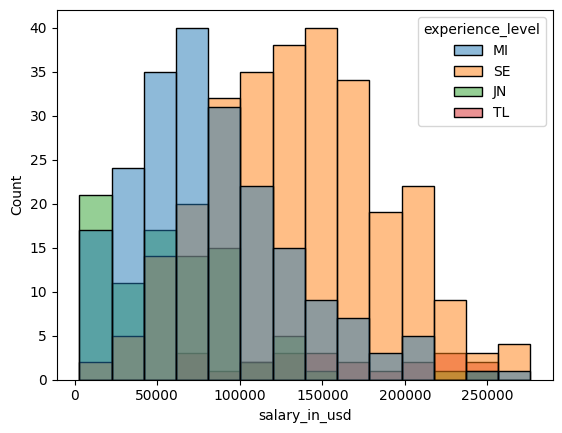

In [14]:
sns.histplot(data=data, x='salary_in_usd', hue='experience_level');

Избавимся от выбросов

In [13]:
data = data[data.salary_in_usd < 300000]

In [15]:
spearmanr(data.salary_in_usd, data.experience_level)
# статистически значимый результат и высокая корреляция

SignificanceResult(statistic=np.float64(0.5579476468827914), pvalue=np.float64(3.795022662679326e-50))

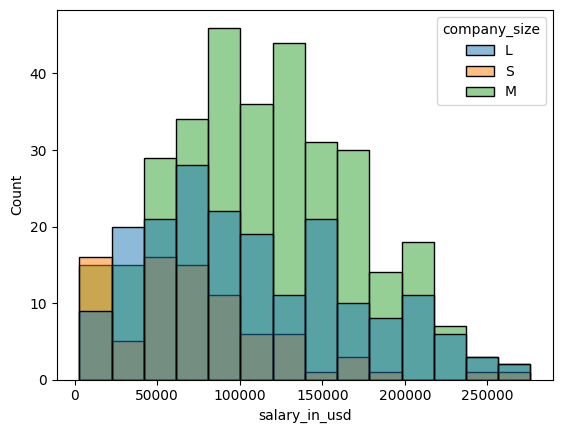

In [16]:
# распределение зарплат по размеру компании
sns.histplot(data=data, x='salary_in_usd', hue='company_size');

In [17]:
spearmanr(data.salary_in_usd, data.company_size)
# стат значимый результат, но низкая и отрицательная корреляция

SignificanceResult(statistic=np.float64(-0.10308939513387676), pvalue=np.float64(0.011726080444722021))

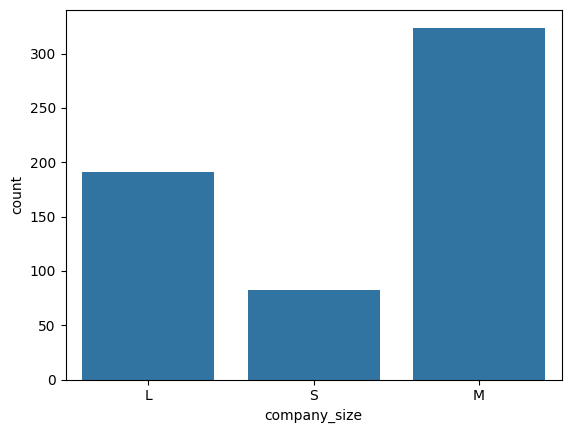

In [18]:
# количество открытых вакансий в компании в зависимости от их размера
sns.countplot(data=data, x='company_size');

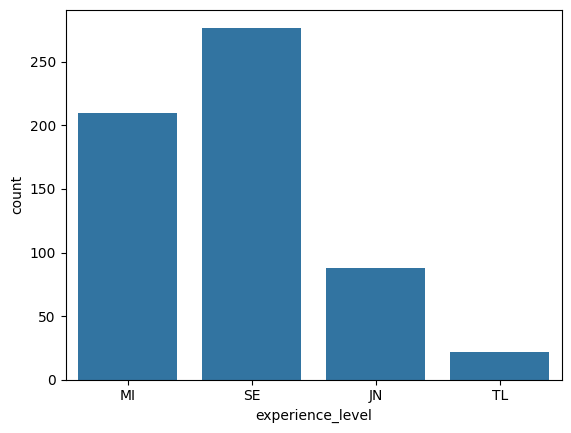

In [19]:
# количество вакансий в компании в зависимости от грейда кандидата
sns.countplot(data=data, x='experience_level');

<b>2. Как распределены позиции (грейды) сотрудников в компаниях разного размера и какие выводы можно сделать на основе полученного распределения?</b>

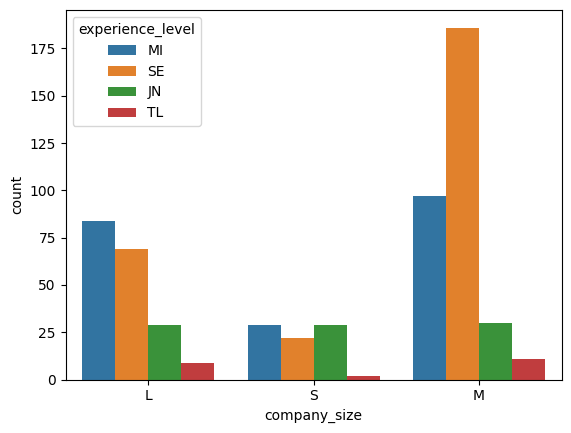

In [20]:
sns.countplot(data=data, x='company_size', hue='experience_level');

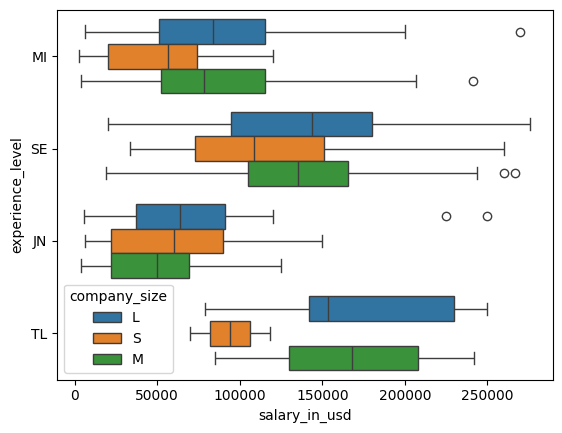

In [21]:
sns.boxplot(data=data, x='salary_in_usd', y='experience_level', hue='company_size');

1. Компании размера М больше нанимают грейд Senior
2. Компании размера L больше нанимаю грейд Middle и выделяют средства, чтобы развивать их до уровня Senior
3. В компании размера S нанимают все уровни равномерно
4. Компании всех размеров редко нанимают грейд TM, меньше всего их нанимают компании S

<b>3. В какую компанию выгоднее устраиваться сотруднику, грейд которого миддл или сеньор?</b>

In [22]:
middle = data[data.experience_level == 'MI']

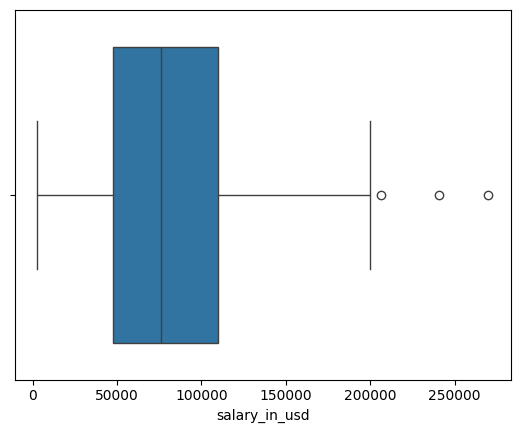

In [23]:
sns.boxplot(data=middle, x='salary_in_usd');

In [24]:
#основные статистики
middle.salary_in_usd.describe()

count       210.000000
mean      82953.142857
std       48222.337602
min        2859.000000
25%       47461.500000
50%       76357.000000
75%      110000.000000
max      270000.000000
Name: salary_in_usd, dtype: float64

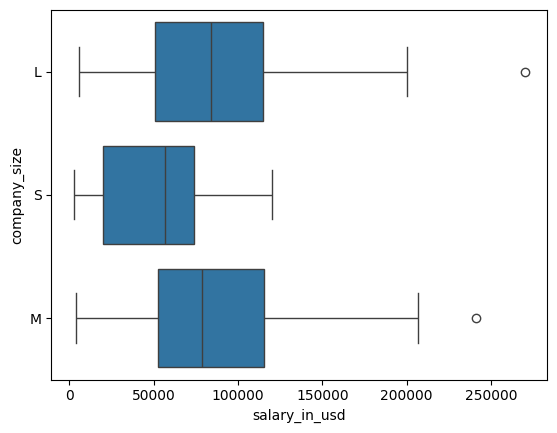

In [25]:
sns.boxplot(data=middle, x='salary_in_usd', y='company_size');

In [26]:
two_way = ols('salary_in_usd ~ company_size', middle).fit()
anova_lm(two_way)

,df,sum_sq,mean_sq,F,PR(>F)
company_size,2.0,3.459172e+10,1.729586e+10,7.931145,0.00048
Residual,207.0,4.514156e+11,2.180752e+09,NaN,NaN


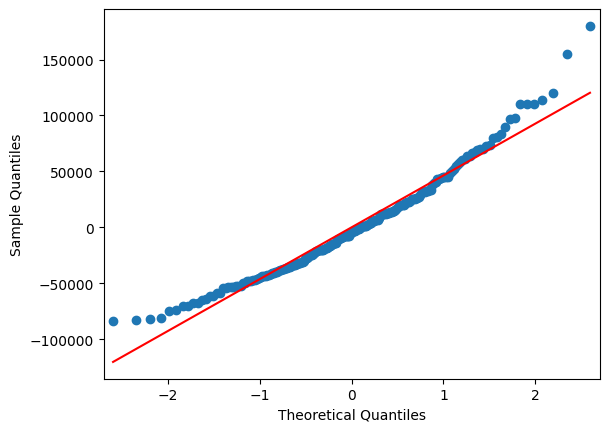

In [27]:
# проверка остатков на нормальность
sm.qqplot(two_way.resid, line='s');

In [28]:
stats.shapiro(two_way.resid)
# проверка на нормальность, остатки распределены нормально, результаты анова надежны

ShapiroResult(statistic=np.float64(0.9632374524384487), pvalue=np.float64(2.8658765515174127e-05))

In [29]:
groups = []
for i, gr in data.groupby(['company_size']):
    groups.append(gr.salary_in_usd)

In [30]:
# тест Левена на равенство дисперсий
stats.levene(*groups)

LeveneResult(statistic=np.float64(4.099257740939009), pvalue=np.float64(0.017056465095709565))

In [31]:
print(pairwise_tukeyhsd(endog=data.salary_in_usd, alpha=0.05, groups=data['company_size'])) #попарные сравнения

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------
     L      M   7305.6873 0.3389  -4910.2542  19521.6287  False
     L      S -34426.2849    0.0 -52105.7952 -16746.7746   True
     M      S -41731.9721    0.0 -58285.7111 -25178.2332   True
---------------------------------------------------------------


In [32]:
senior = data[data.experience_level == 'SE']

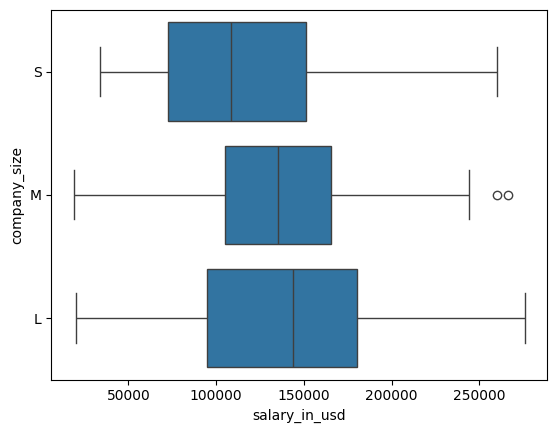

In [33]:
sns.boxplot(data=senior, x='salary_in_usd', y='company_size');

In [34]:
two_way = ols('salary_in_usd ~ company_size', senior).fit()
anova_lm(two_way)

,df,sum_sq,mean_sq,F,PR(>F)
company_size,2.0,9.408313e+09,4.704156e+09,1.807669,0.165987
Residual,274.0,7.130390e+11,2.602332e+09,NaN,NaN


1. Специалисту грейда Middle выгоднее работать в компаниях размера M и L
2. Зарплата Senior специалиста не зависит от размера компании